# House Price Prediction using Linear Regression

This notebook demonstrates a complete Machine Learning workflow using the California Housing Dataset to predict house prices using Linear Regression.

## 1. Import Libraries

Importing all necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_theme(style='whitegrid')

## 2. Load Dataset

Loading the California Housing dataset from `sklearn.datasets`.

In [2]:
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['MedHouseVal'] = california.target

# Display first five rows
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## 3. Exploratory Data Analysis (EDA)

### 3.1 Dataset Overview

In [3]:
print('Dataset Shape:', df.shape)

Dataset Shape: (20640, 9)


### 3.2 Dataset Information

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### 3.3 Statistical Summary

In [5]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


### 3.4 Missing Values

Checking for any null values in the dataset.

In [6]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### 3.5 Duplicate Values

Checking for duplicate rows in the dataset.

In [7]:
print('Duplicate Rows:', df.duplicated().sum())

Duplicate Rows: 0


### 3.6 Correlation Heatmap

Visualizing the correlation matrix to understand the linear relationships between features and the target variable.

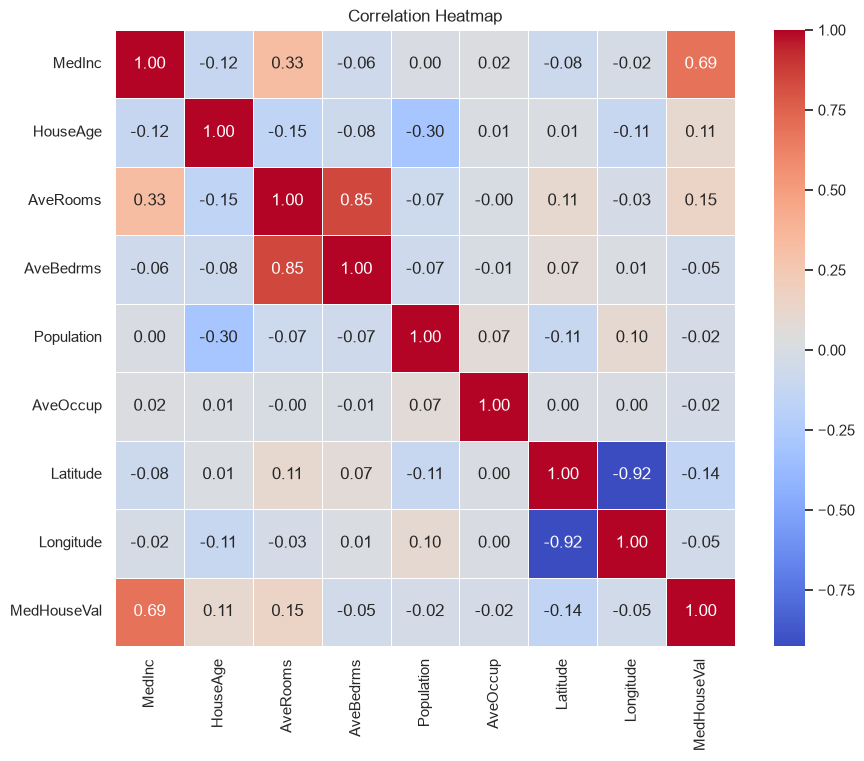

In [8]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### 3.7 Histograms

Plotting histograms to analyze the distribution of each numerical feature.

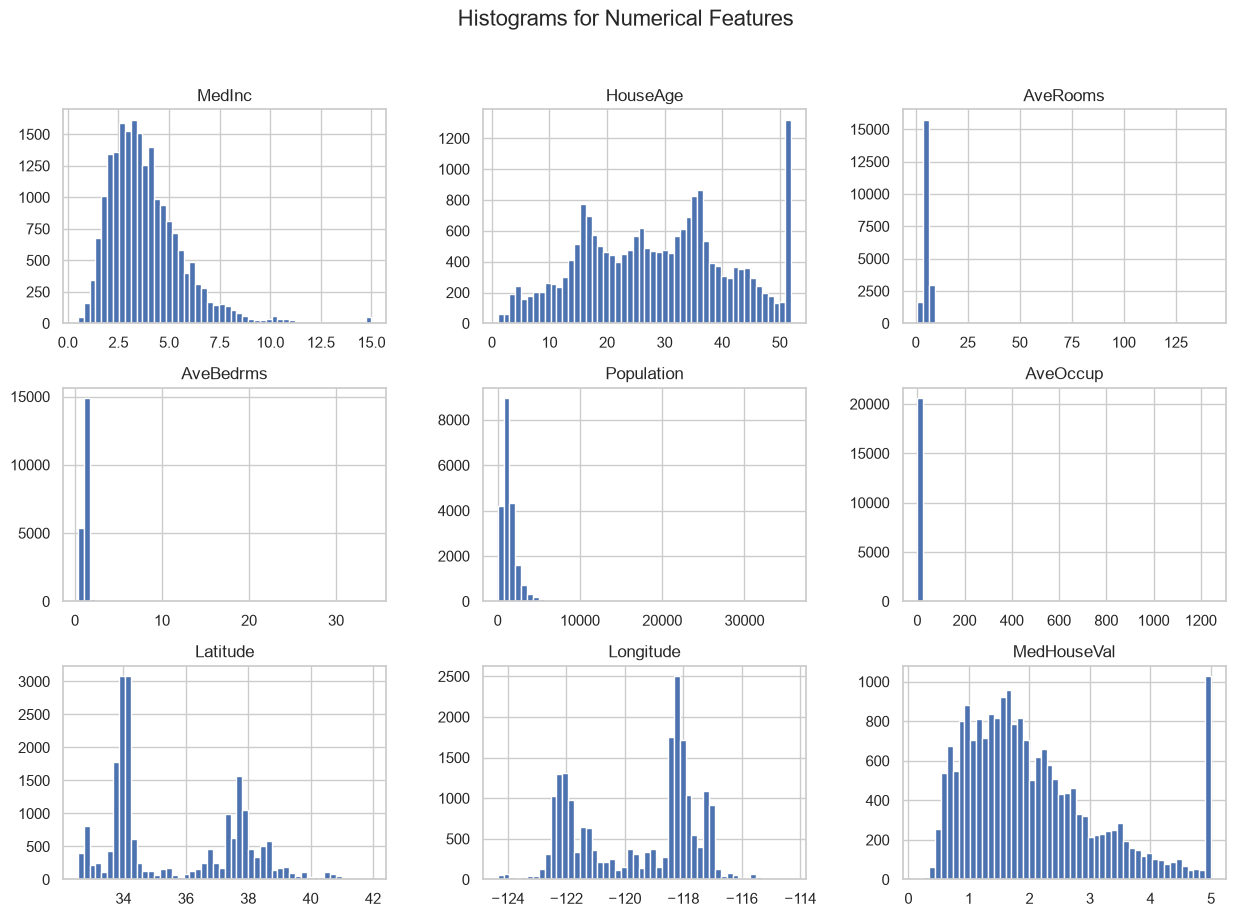

In [9]:
df.hist(bins=50, figsize=(15, 10))
plt.suptitle('Histograms for Numerical Features', fontsize=16)
plt.show()

### 3.8 Boxplots

Identifying potential outliers in the dataset using boxplots.

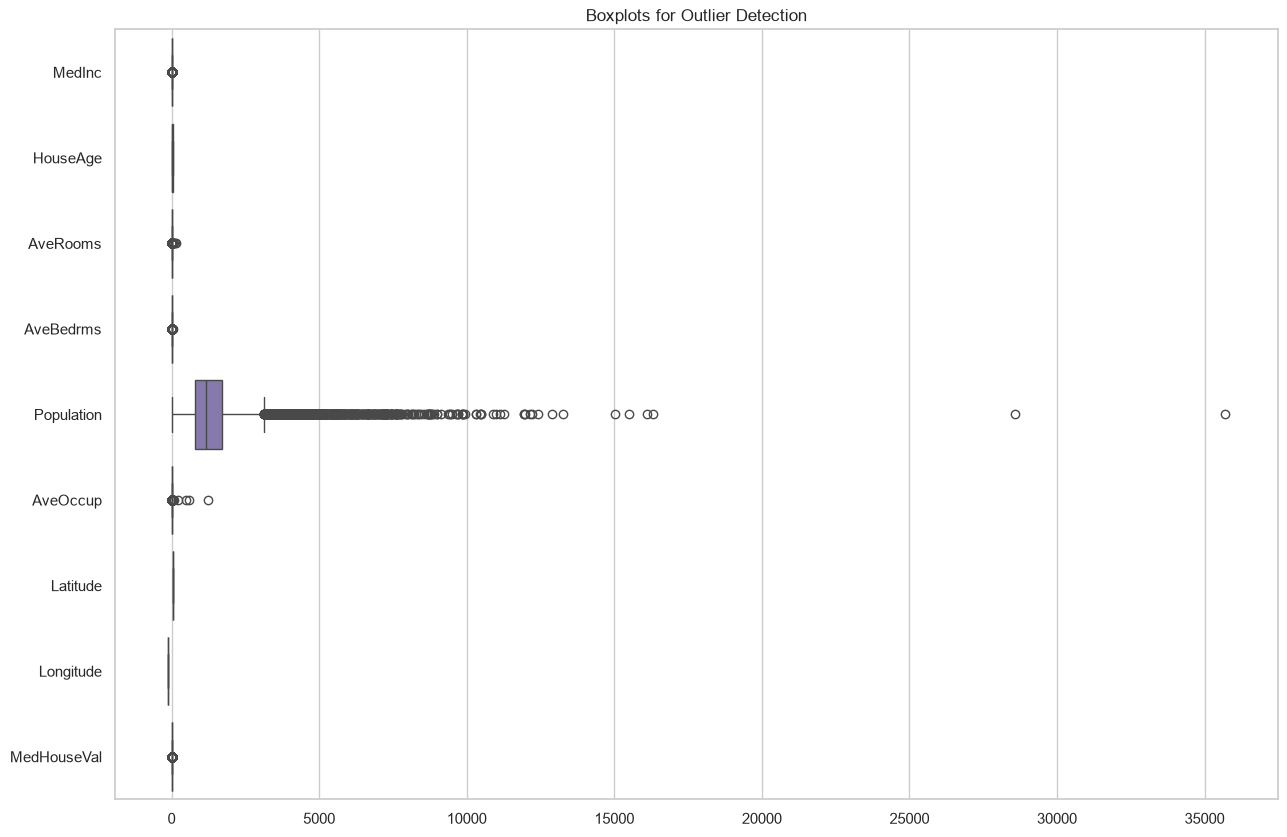

In [10]:
plt.figure(figsize=(15, 10))
sns.boxplot(data=df, orient='h')
plt.title('Boxplots for Outlier Detection')
plt.show()

### 3.9 Pairplot

Visualizing pairwise relationships for important features.

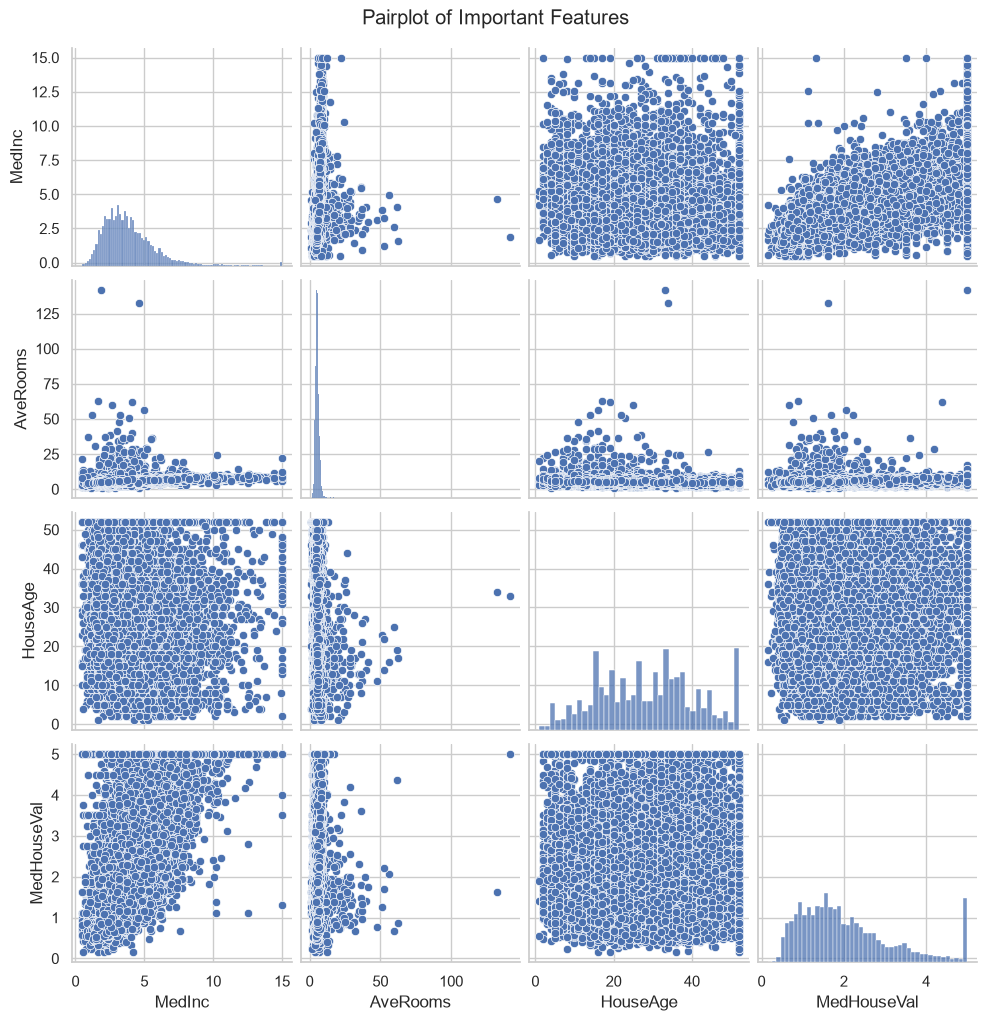

In [11]:
important_features = ['MedInc', 'AveRooms', 'HouseAge', 'MedHouseVal']
sns.pairplot(df[important_features])
plt.suptitle('Pairplot of Important Features', y=1.02)
plt.show()

## 4. Data Preprocessing & Train-Test Split

Splitting the data into features (X) and target (y), and then into training and testing sets (80:20).

In [12]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# Train-Test Split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Training set shape:', X_train.shape)
print('Testing set shape:', X_test.shape)

Training set shape: (16512, 8)
Testing set shape: (4128, 8)


## 5. Model Training

Training a Multiple Linear Regression model on the training data.

In [13]:
model = LinearRegression()
model.fit(X_train, y_train)
print('Model training complete.')

Model training complete.


## 6. Model Evaluation

Predicting on test data and evaluating performance using standard regression metrics.

In [14]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R� Score: {r2:.4f}')

Mean Absolute Error (MAE): 0.5332
Mean Squared Error (MSE): 0.5559
Root Mean Squared Error (RMSE): 0.7456
R� Score: 0.5758


### 6.1 Feature Coefficients

Displaying the coefficients for each feature to understand their impact on house prices.

In [15]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)
coefficients

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


### 6.2 Actual vs Predicted Plot

Visualizing how well the predicted prices match the actual prices.

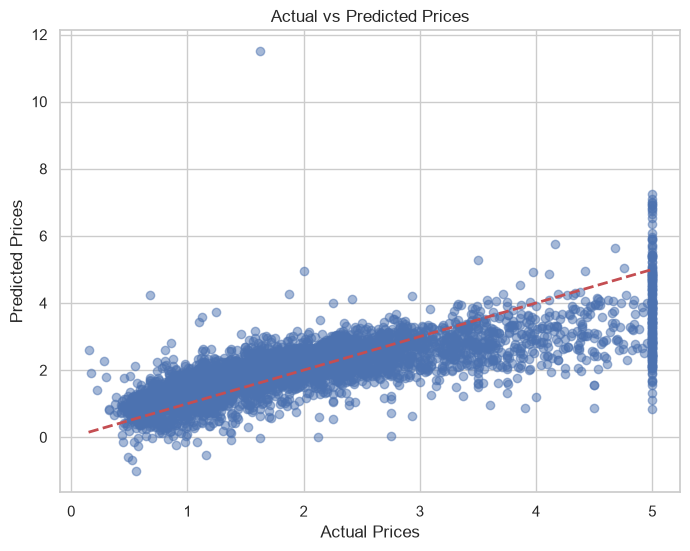

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()

### 6.3 Residual Plot

Plotting the distribution of residuals (errors) to check if they are normally distributed.

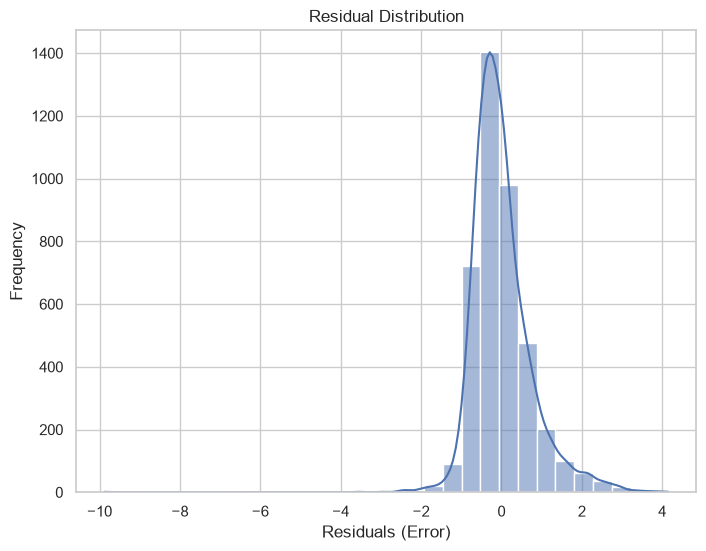

In [17]:
plt.figure(figsize=(8, 6))
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, bins=30)
plt.xlabel('Residuals (Error)')
plt.ylabel('Frequency')
plt.title('Residual Distribution')
plt.show()

## 7. Save Model

Saving the trained model using Pickle for future deployment.

In [18]:
import os
os.makedirs('../model', exist_ok=True)
with open('../model/house_price_model.pkl', 'wb') as file:
    pickle.dump(model, file)
print('Model saved successfully to ../model/house_price_model.pkl')

Model saved successfully to ../model/house_price_model.pkl
